# Simulation 2 — Directional coupler transmission vs gap

Two parallel waveguides exchange power via **evanescent coupling**. 

FDTD gives cross-port split vs gap. We extract effective κ(g) = arcsin(√η)/L from each simulation, compare to Project 1’s unfitted model, and overlay CMT with κ fitted to FDTD.



In [ ]:
print("kernel ok")

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tidy3d as td

from fdtd_pic.analytics.cmt import (
    cross_power_curve,
    cross_power_curve_fitted,
    fit_kappa_exponential,
    kappa_curve_from_ratios,
)
from fdtd_pic.config import (
    COUPLER_L_EFF,
    COUPLER_SWEEP_PREFIX,
    GAP_SWEEP,
)
from fdtd_pic.coupler import build_coupler_simulation, coupling_ratio, extract_port_powers
from fdtd_pic.plotting import apply_style, save_figure
from fdtd_pic.sweep import sweep_param

apply_style()

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    os.chdir(ROOT.parent)
print("cwd:", Path.cwd())


cwd: /workspaces/fdtd-pic-simulations


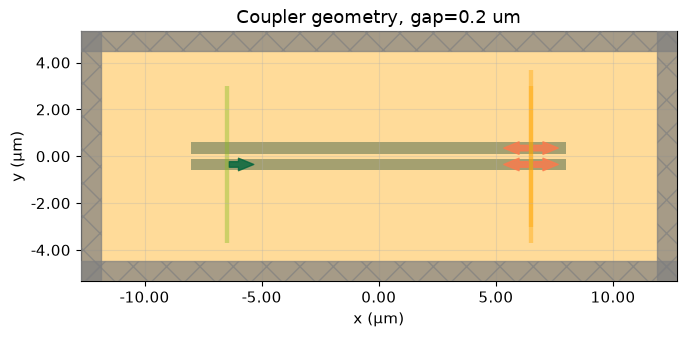

In [2]:
# Single-gap sanity check — always plot geometry before cloud submit
gap_test = 0.2
sim = build_coupler_simulation(gap=gap_test)
sim.plot(z=0)
plt.title(f'Coupler geometry, gap={gap_test} um')
plt.show() # looks good, figuring out if two guides run side by side, how much power couples (coupled mode theory)

# no bends needed here for power coupling test
# power cross over scaling as sin(kL)^2


In [ ]:
# Run one job first (or load from cache)
sim_data = web.run(sim, task_name='coupler_gap0.2', verbose=True)
powers = extract_port_powers(sim_data)
print(powers)
print('Coupling ratio:', coupling_ratio(sim_data))
print('Output sum:', powers.total_output)

In [ ]:
# one cahced result - testing loading works properly

import tidy3d as td

sim_data = td.SimulationData.from_file(".tidy3d_cache/coupler_v3_gap=0.2000.hdf5")
powers = extract_port_powers(sim_data)
print(powers)
print("Coupling ratio:", coupling_ratio(sim_data))
print("Output sum:", powers.total_output)

CouplerPortPowers(bar_in=1.0, bar_through=0.08489716106802674, cross_through=0.0, cross_out=0.03251354496497278)
Coupling ratio: 0.2769214670750255
Output sum: 0.11741070603299952


CouplerPortPowers(bar_in=1.0, bar_through=0.08489716106802674, cross_through=0.0, cross_out=0.03251354496497278)
Coupling ratio: 0.2769214670750255
Output sum: 0.11741070603299952
Loading cached: coupler_v3_gap=0.1000
Loading cached: coupler_v3_gap=0.1500
Loading cached: coupler_v3_gap=0.2000
Loading cached: coupler_v3_gap=0.2500
Loading cached: coupler_v3_gap=0.3000
Loading cached: coupler_v3_gap=0.3500
Loading cached: coupler_v3_gap=0.4000
FDTD κ(g): ['0.0893', '0.0561', '0.0346', '0.0246', '0.0190', '0.0151', '0.0124']
Fitted: κ₀=0.1949, decay=0.124 µm


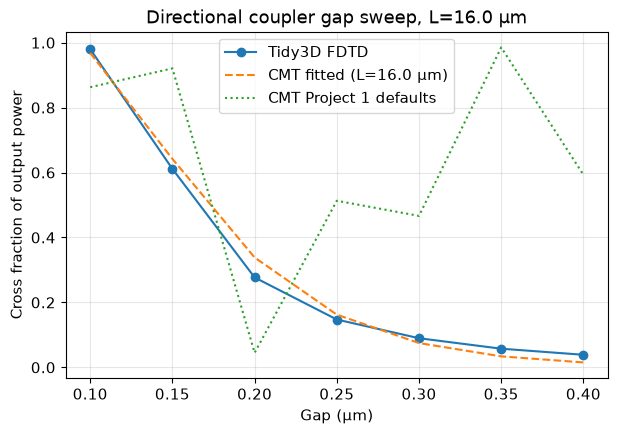

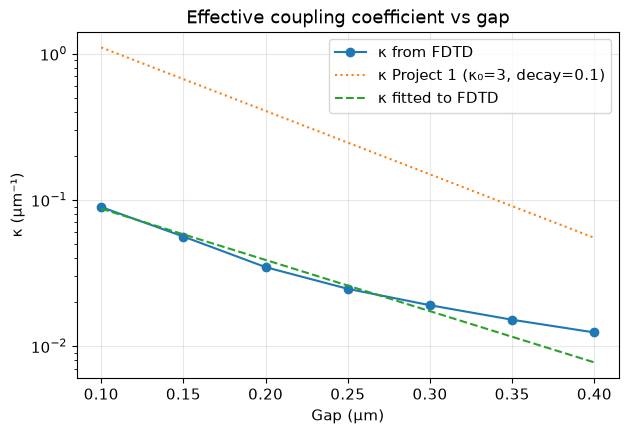

In [2]:
sim_data = td.SimulationData.from_file(
    f".tidy3d_cache/{COUPLER_SWEEP_PREFIX}_gap=0.2000.hdf5"
)
powers = extract_port_powers(sim_data)
print(powers)
print("Coupling ratio:", coupling_ratio(sim_data))
print("Output sum:", powers.total_output)

# Load cached FDTD sweep (no cloud)
results = sweep_param(
    build_coupler_simulation,
    param_name="gap",
    values=GAP_SWEEP,
    task_prefix=COUPLER_SWEEP_PREFIX,
    cache_dir=".tidy3d_cache",
    verbose=True,
)

ratios = [coupling_ratio(results[g]) for g in GAP_SWEEP]

# κ from FDTD
kappa_fdtd = kappa_curve_from_ratios(GAP_SWEEP, ratios, COUPLER_L_EFF)
kappa_0, gap_decay = fit_kappa_exponential(GAP_SWEEP, kappa_fdtd)

# Three overlays
cmt_default = cross_power_curve(GAP_SWEEP, COUPLER_L_EFF)  # Project 1 defaults
cmt_fitted = cross_power_curve_fitted(GAP_SWEEP, COUPLER_L_EFF, kappa_0, gap_decay)

print("FDTD κ(g):", [f"{k:.4f}" for k in kappa_fdtd])
print(f"Fitted: κ₀={kappa_0:.4f}, decay={gap_decay:.3f} µm")

# --- Plot 1: cross fraction vs gap ---
fig, ax = plt.subplots()
ax.plot(GAP_SWEEP, ratios, "o-", label="Tidy3D FDTD")
ax.plot(GAP_SWEEP, cmt_fitted, "--", label=f"CMT fitted (L={COUPLER_L_EFF} µm)")
ax.plot(GAP_SWEEP, cmt_default, ":", label="CMT Project 1 defaults")
ax.set_xlabel("Gap (µm)")
ax.set_ylabel("Cross fraction of output power")
ax.set_title(f"Directional coupler gap sweep, L={COUPLER_L_EFF} µm")
ax.legend()
save_figure(fig, "assets/coupler_ratio_vs_gap.png")
plt.show()


import math

kappa_toy = [3.0 * math.exp(-g / 0.1) for g in GAP_SWEEP]

fig, ax = plt.subplots()
ax.semilogy(GAP_SWEEP, kappa_fdtd, "o-", label="κ from FDTD")
ax.semilogy(GAP_SWEEP, kappa_toy, ":", label="κ Project 1 (κ₀=3, decay=0.1)")
ax.semilogy(
    GAP_SWEEP,
    [kappa_0 * math.exp(-g / gap_decay) for g in GAP_SWEEP],
    "--",
    label="κ fitted to FDTD",
)
ax.set_xlabel("Gap (µm)")
ax.set_ylabel("κ (µm⁻¹)")
ax.set_title("Effective coupling coefficient vs gap")
ax.legend()
save_figure(fig, "assets/coupler_kappa_vs_gap.png")
plt.show()



In [ ]:
#The notebook cell for running simulations,i called my data from terminal (see above)
results = sweep_param(
    build_coupler_simulation,
    param_name='gap',
    values=GAP_SWEEP,
    task_prefix='coupler',
)
ratios = [coupling_ratio(results[g]) for g in GAP_SWEEP]
cmt = cross_power_curve(GAP_SWEEP, COUPLING_LENGTH)

fig, ax = plt.subplots()
ax.plot(GAP_SWEEP, ratios, 'o-', label='Tidy3D FDTD')
ax.plot(GAP_SWEEP, cmt, '--', label='CMT (phenomenological)')
ax.set_xlabel('Gap (um)')
ax.set_ylabel('Cross power fraction')
ax.set_title(f'Directional coupler, L={COUPLING_LENGTH} um')
ax.legend()
save_figure(fig, '../assets/coupler_ratio_vs_gap.png')
plt.show()

## Key takeaway

- **FDTD:** smaller gap => stronger coupling => higher cross fraction 
- **κ extraction:** η ≈ sin²(κL) with L = 16 µm gives a smooth κ(g) decreasing with gap.
- **Project 1 default CMT** (κ₀=3, decay=0.1 µm) is not calibrated to this 3D cell and oscillates when plugged into sin²(κL). *USES UNFITTED PARAMETERS**, does not represent the weak coupling that we see from our simulation
- **FDTD-fitted κ(g)** gives a sensible CMT overlay; FDTD remains the authoritative result.


Note on the graph:
- FDTD k decays faster than a single exponential at small gaps and more slowly at large gaps => exponential fit is qualitative and the fitted line is hence not as accurate 